# Real World Classification

## Load data

Import the necessary libraries

In [81]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install graphviz

In [82]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed = 40
np.random.seed(seed)

load the data

In [83]:
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


---
## Q3 Data Preprocessing
---

---
## Report Missing Columns, Median, std Before Imputation
---

In [84]:
missing_counts = df.isnull().sum()
missing_cols = missing_counts[missing_counts > 0].index.tolist()

print("Columns with missing values:")
print(missing_counts[missing_counts > 0])

print("\nMedian before imputation:")
print(df[missing_cols].median())

print("\nStandard deviation before imputation:")
print(df[missing_cols].std())

Columns with missing values:
SepalLengthCm     28
SepalWidthCm      57
PetalLengthCm    150
PetalWidthCm      22
BranchLength      24
dtype: int64

Median before imputation:
SepalLengthCm     6.300000
SepalWidthCm      2.900000
PetalLengthCm     5.085612
PetalWidthCm      1.600000
BranchLength     16.300000
dtype: float64

Standard deviation before imputation:
SepalLengthCm    1.037115
SepalWidthCm     0.389564
PetalLengthCm    1.582807
PetalWidthCm     0.706689
BranchLength     1.035228
dtype: float64


---
### Preprocessing Function with KKN Imputation
---

In [85]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    df = df.copy()

    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Replace the missing values using Nearest Neighbors Imputation
    imputer = KNNImputer(n_neighbors=5)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])

    return df, feature_cols

df, feature_cols = data_preprocessing(df)

---
### Report Median/std After Imputation and Comparison
---

In [86]:
print("Median after KNN imputation:")
print(df[missing_cols].median())

print("\nStandard deviation after KNN imputation:")
print(df[missing_cols].std())

comparison_df = pd.DataFrame({
    'Median Before': pd.read_csv('data/NYCU_Iris.csv')[missing_cols].median(),
    'Median After': df[missing_cols].median(),
    'Std Before': pd.read_csv('data/NYCU_Iris.csv')[missing_cols].std(),
    'Std After': df[missing_cols].std()
})

print("\nComparison before vs after imputation:")
print(comparison_df)

Median after KNN imputation:
SepalLengthCm     6.300000
SepalWidthCm      2.900000
PetalLengthCm     5.035683
PetalWidthCm      1.700000
BranchLength     16.300000
dtype: float64

Standard deviation after KNN imputation:
SepalLengthCm    1.009275
SepalWidthCm     0.372434
PetalLengthCm    1.514955
PetalWidthCm     0.694645
BranchLength     1.011012
dtype: float64

Comparison before vs after imputation:
               Median Before  Median After  Std Before  Std After
SepalLengthCm       6.300000      6.300000    1.037115   1.009275
SepalWidthCm        2.900000      2.900000    0.389564   0.372434
PetalLengthCm       5.085612      5.035683    1.582807   1.514955
PetalWidthCm        1.600000      1.700000    0.706689   0.694645
BranchLength       16.300000     16.300000    1.035228   1.011012


In [87]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

In [88]:
from sklearn.feature_selection import r_regression

---
### Full Q4 (a, b, c, and d)
---

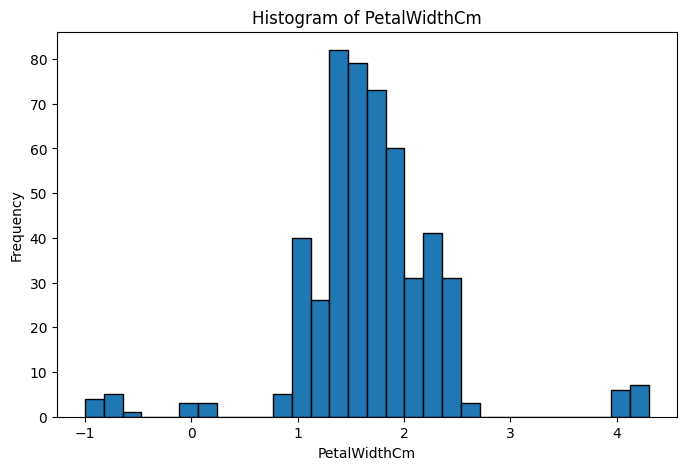

Largest positive correlation with PetalWidthCm:
PetalWidthCompactness: 0.991670

Top 5 strongest negative correlations with PetalWidthCm:
SepalWidthMajorAxis     -0.096350
SepalGlossIndex         -0.095200
SepalWidthCompactness   -0.088496
SepalWidthCurvature     -0.081334
SepalWidthMinorAxis     -0.074392
dtype: float64


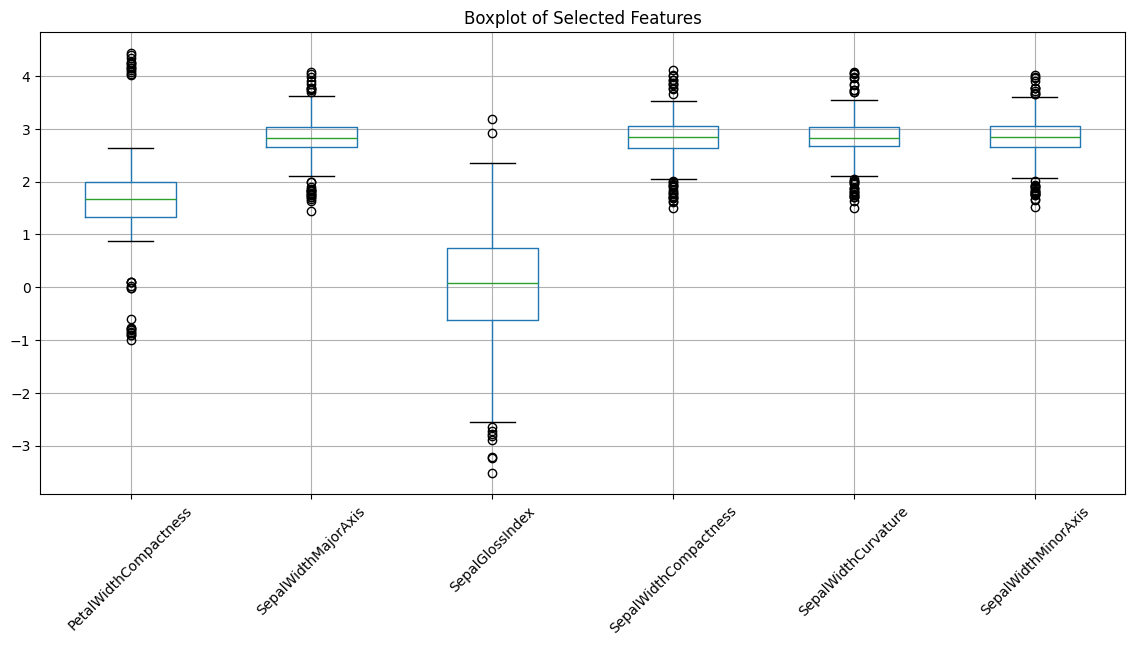

In [89]:
# Q4(a) Histogram of PetalWidthCm
plt.figure(figsize=(8, 5))
plt.hist(df['PetalWidthCm'], bins=30, edgecolor='black')
plt.title('Histogram of PetalWidthCm')
plt.xlabel('PetalWidthCm')
plt.ylabel('Frequency')
plt.show()

# Q4(b) and Q4(c): Pearson correlation with PetalWidthCm
candidate_features = [c for c in df.columns if c not in ['Id', 'Species', 'PetalWidthCm']]
X_corr = df[candidate_features]
y_corr = df['PetalWidthCm']

corr_values = r_regression(X_corr, y_corr)
corr_series = pd.Series(corr_values, index=candidate_features).sort_values(ascending=False)

# Largest positive correlation
largest_positive_feature = corr_series.idxmax()
largest_positive_value = corr_series.max()

print("Largest positive correlation with PetalWidthCm:")
print(f"{largest_positive_feature}: {largest_positive_value:.6f}")

# Top 5 strongest negative correlations
top5_negative = corr_series.sort_values().head(5)
print("\nTop 5 strongest negative correlations with PetalWidthCm:")
print(top5_negative)

# Q4(d) Boxplot for 1 positive + 5 negative features
selected_features = [largest_positive_feature] + top5_negative.index.tolist()

plt.figure(figsize=(14, 6))
df[selected_features].boxplot()
plt.title('Boxplot of Selected Features')
plt.xticks(rotation=45)
plt.show()

---
### Prepare the Data
---

In [90]:
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0

X = df[feature_cols].values.astype(float)
y = df['Species'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


---
## Q5 Regularization
---

In [91]:
from model.linear_model import LinearModel
from model.metrics import logloss, evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid

---
### Helper Function
---

In [92]:
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

def train_realworld_model(X_train, y_train, lr=0.1, n_iteration=10000, reg_type='', reg_lambda=0.0):
    np.random.seed(seed)
    model = LinearModel(
        dim=X_train.shape[1],
        is_reg=False,
        loss_fn=loss_fn,
        act_fn=act_fn,
        grad_fn=grad_fn
    )
    model.fit(
        X_train,
        y_train,
        lr=lr,
        n_iteration=n_iteration,
        val_ratio=0.2,
        reg_type=reg_type,
        reg_lambda=reg_lambda
    )
    return model

---
### Q5 (a): No Regularization
---

50. Training loss: 0.6572950512169217, Val loss:0.6699856821878871
100. Training loss: 0.6226307711490021, Val loss:0.6436636316717124
150. Training loss: 0.5968536106438317, Val loss:0.6248019734101419
200. Training loss: 0.5770724410855091, Val loss:0.6109725987973054
250. Training loss: 0.5614500987624708, Val loss:0.6006341363275265
300. Training loss: 0.5488013196405573, Val loss:0.5927862551965061
350. Training loss: 0.5383413721955611, Val loss:0.5867610521735693
400. Training loss: 0.5295356518896498, Val loss:0.5820996162672264
450. Training loss: 0.5220096572557988, Val loss:0.5784781297261021
500. Training loss: 0.51549415543084, Val loss:0.5756625817533594
550. Training loss: 0.5097909798441069, Val loss:0.5734802622069771
600. Training loss: 0.5047511496548615, Val loss:0.5718013280805994
650. Training loss: 0.5002605183372977, Val loss:0.5705265741611238
700. Training loss: 0.49623013467643184, Val loss:0.5695791245134203
750. Training loss: 0.49258962365573294, Val loss:

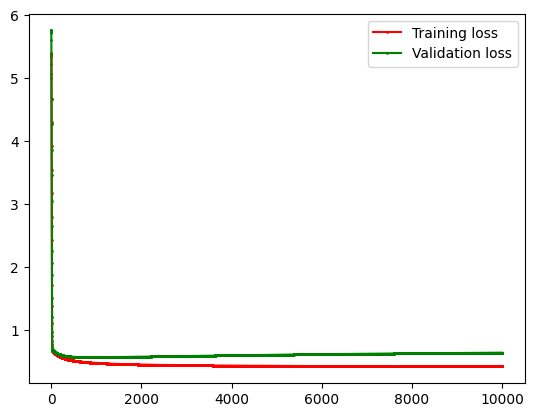

Model parameters (weights): [[-3.16335176]
 [ 1.08853101]
 [ 0.71350466]
 [-0.8911023 ]
 [ 1.66226609]
 [ 0.5786216 ]
 [ 0.3065608 ]
 [-0.22656249]
 [ 0.60023229]
 [ 1.34775177]
 [ 1.12105697]
 [ 0.13582979]
 [ 0.91532985]
 [-0.25514498]
 [-1.06000782]
 [ 0.02580588]
 [ 1.29641721]
 [ 0.46583142]
 [ 0.708017  ]
 [-0.36421518]
 [ 1.03551315]
 [ 0.91255039]
 [-0.28515676]
 [ 0.96740435]
 [-0.2501886 ]
 [ 1.86846412]
 [ 1.65606493]
 [ 1.427259  ]
 [ 1.94460281]
 [ 2.01542746]
 [ 1.41402383]
 [-2.26918045]
 [ 1.53705993]
 [-0.36344481]
 [ 0.19244885]
 [-1.44748147]
 [ 0.70819491]
 [-1.04435298]
 [-2.97198857]
 [-0.42692794]
 [-1.24261354]
 [-0.41796296]
 [-0.98414705]
 [-1.22924233]
 [ 0.50058516]
 [-0.04456719]
 [ 0.02405468]
 [ 0.32226938]
 [-0.64850895]
 [-0.66593166]
 [-0.48056443]
 [ 0.32707679]
 [ 0.17495455]
 [-0.61593367]
 [-0.36535728]
 [ 0.49267489]
 [-0.85987899]
 [-1.26373002]
 [-0.28735217]
 [ 0.57001036]
 [-1.02409882]
 [ 0.71907016]
 [ 0.6272286 ]
 [-1.5667075 ]
 [ 0.1079384

In [93]:
model_no_reg = train_realworld_model(
    X_train, y_train,
    lr=0.1,
    n_iteration=10000,
    reg_type='',
    reg_lambda=0.0
)

print("Model parameters (weights):", model_no_reg.W)
print("Sum of absolute values of weights:", np.sum(np.abs(model_no_reg.W)))

---
### Q5 (a): L2 with Lambda = 0.01
---

50. Training loss: 0.6572929744907086, Val loss:0.6699828194400217
100. Training loss: 0.622637070859397, Val loss:0.6436662386803188
150. Training loss: 0.5968724567755489, Val loss:0.6248125819822072
200. Training loss: 0.5771051326187799, Val loss:0.6109911766151703
250. Training loss: 0.5614967431436563, Val loss:0.6006595362014496
300. Training loss: 0.5488615550371709, Val loss:0.592816880200311
350. Training loss: 0.5384146721109383, Val loss:0.5867951648523863
400. Training loss: 0.5296214516465223, Val loss:0.5821354839154358
450. Training loss: 0.5221074045422048, Val loss:0.5785140918733357
500. Training loss: 0.5156033285344711, Val loss:0.575697079625259
550. Training loss: 0.5099110923718569, Val loss:0.5735118491814875
600. Training loss: 0.5048817498726621, Val loss:0.5718286705532784
650. Training loss: 0.5004011866212237, Val loss:0.5705484476177356
700. Training loss: 0.4963804805267807, Val loss:0.5695944073134431
750. Training loss: 0.4927492828335417, Val loss:0.5

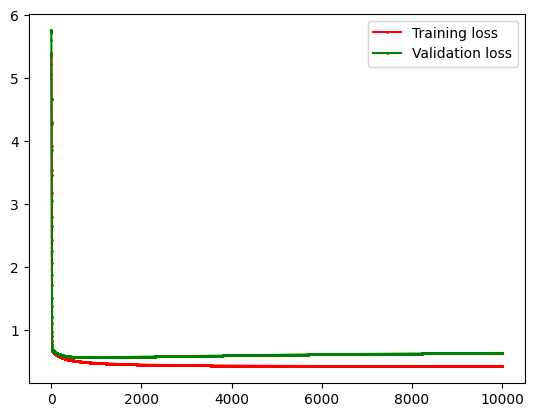

Model parameters (weights): [[-3.04491277]
 [ 1.06690025]
 [ 0.6919335 ]
 [-0.85765019]
 [ 1.62211418]
 [ 0.56005118]
 [ 0.30158619]
 [-0.19463749]
 [ 0.57958933]
 [ 1.32752235]
 [ 1.08574484]
 [ 0.15657535]
 [ 0.90839498]
 [-0.23907741]
 [-1.02912786]
 [ 0.03492654]
 [ 1.25176991]
 [ 0.46155106]
 [ 0.67736629]
 [-0.3360695 ]
 [ 0.99104444]
 [ 0.88548156]
 [-0.25831271]
 [ 0.92720969]
 [-0.2240548 ]
 [ 1.83330247]
 [ 1.63715657]
 [ 1.42059956]
 [ 1.90523001]
 [ 1.97682052]
 [ 1.40626307]
 [-2.21460197]
 [ 1.49055105]
 [-0.3597555 ]
 [ 0.18556675]
 [-1.40617771]
 [ 0.68446346]
 [-1.02786244]
 [-2.91241716]
 [-0.42070369]
 [-1.21899384]
 [-0.41412216]
 [-0.97368391]
 [-1.20316405]
 [ 0.48756144]
 [-0.06099954]
 [ 0.01549635]
 [ 0.30103751]
 [-0.63725608]
 [-0.65781288]
 [-0.47183837]
 [ 0.3066131 ]
 [ 0.16544312]
 [-0.60674983]
 [-0.35497642]
 [ 0.47752786]
 [-0.84634486]
 [-1.24388514]
 [-0.28766676]
 [ 0.53941665]
 [-1.00871619]
 [ 0.69605025]
 [ 0.60968265]
 [-1.54064268]
 [ 0.0956521

In [94]:
model_l2_001 = train_realworld_model(
    X_train, y_train,
    lr=0.1,
    n_iteration=10000,
    reg_type='l2',
    reg_lambda=0.01
)

print("Model parameters (weights):", model_l2_001.W)
print("Sum of absolute values of weights:", np.sum(np.abs(model_l2_001.W)))

---
### Q5 (a): L2 with Lambda = 1
---

50. Training loss: 0.6571098767748111, Val loss:0.6697244267768969
100. Training loss: 0.6233246012236595, Val loss:0.643999865252734
150. Training loss: 0.5988483414837363, Val loss:0.6260046211970154
200. Training loss: 0.580503081098561, Val loss:0.6130584747744167
250. Training loss: 0.5663340514385814, Val loss:0.6035153895899893
300. Training loss: 0.555109610778399, Val loss:0.5963362172188005
350. Training loss: 0.5460282664733441, Val loss:0.5908438177965458
400. Training loss: 0.5385508819400877, Val loss:0.5865832541498985
450. Training loss: 0.5323033478328499, Val loss:0.5832403037115937
500. Training loss: 0.5270186638253865, Val loss:0.5805925757006578
550. Training loss: 0.5225014437416007, Val loss:0.5784792861358807
600. Training loss: 0.5186055098416564, Val loss:0.5767820163311911
650. Training loss: 0.5152193449448941, Val loss:0.5754121279039557
700. Training loss: 0.5122563954812427, Val loss:0.5743023265172252
750. Training loss: 0.5096484503192897, Val loss:0.5

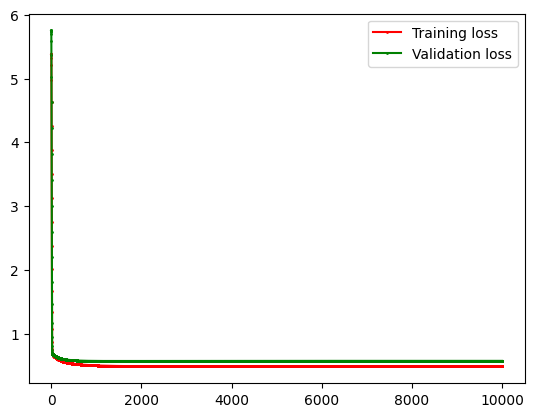

Model parameters (weights): [[-0.67367191]
 [ 0.48871783]
 [ 0.17973896]
 [-0.01441526]
 [ 0.80396647]
 [ 0.31703553]
 [ 0.20008657]
 [ 0.28810773]
 [ 0.33015999]
 [ 0.52360076]
 [ 0.40323486]
 [ 0.3778058 ]
 [ 0.47881443]
 [ 0.02756468]
 [-0.14442614]
 [ 0.10543009]
 [ 0.24329265]
 [ 0.19115282]
 [ 0.1390483 ]
 [ 0.13118977]
 [ 0.22693633]
 [ 0.27872029]
 [ 0.15166806]
 [ 0.2457706 ]
 [ 0.16492078]
 [ 0.85276969]
 [ 0.86812361]
 [ 0.87351467]
 [ 0.88922733]
 [ 0.91021254]
 [ 0.87363237]
 [-0.71611664]
 [ 0.33688178]
 [-0.22246374]
 [-0.00511053]
 [-0.36642025]
 [ 0.08091502]
 [-0.45786534]
 [-1.16838721]
 [-0.18598461]
 [-0.50218181]
 [-0.21872289]
 [-0.56237102]
 [-0.43937779]
 [ 0.10080916]
 [-0.24072984]
 [-0.17200626]
 [-0.13673927]
 [-0.34469301]
 [-0.35869966]
 [-0.21152161]
 [-0.11001394]
 [-0.08477857]
 [-0.30106673]
 [-0.12436427]
 [ 0.05426756]
 [-0.41636498]
 [-0.58113397]
 [-0.24636433]
 [-0.08876187]
 [-0.55101483]
 [ 0.10698488]
 [ 0.17934474]
 [-0.6301461 ]
 [-0.1842545

In [95]:
model_l2_1 = train_realworld_model(
    X_train, y_train,
    lr=0.1,
    n_iteration=10000,
    reg_type='l2',
    reg_lambda=1
)

print("Model parameters (weights):", model_l2_1.W)
print("Sum of absolute values of weights:", np.sum(np.abs(model_l2_1.W)))

---
### Q5 (a): L2 with Lambda = 100
---

50. Training loss: 0.6750694290943433, Val loss:0.6840309642470094
100. Training loss: 0.6747548127534179, Val loss:0.6839309748933531
150. Training loss: 0.6747488372001222, Val loss:0.6839298599003173
200. Training loss: 0.6747487203171995, Val loss:0.6839298551190556
250. Training loss: 0.6747487180286232, Val loss:0.6839298554515596
300. Training loss: 0.6747487179838312, Val loss:0.6839298554687433
350. Training loss: 0.6747487179829557, Val loss:0.6839298554693461
400. Training loss: 0.6747487179829386, Val loss:0.6839298554693646
450. Training loss: 0.6747487179829381, Val loss:0.683929855469365
500. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
550. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
600. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
650. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
700. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
750. Training loss: 0.6747487179829382, Val loss:0

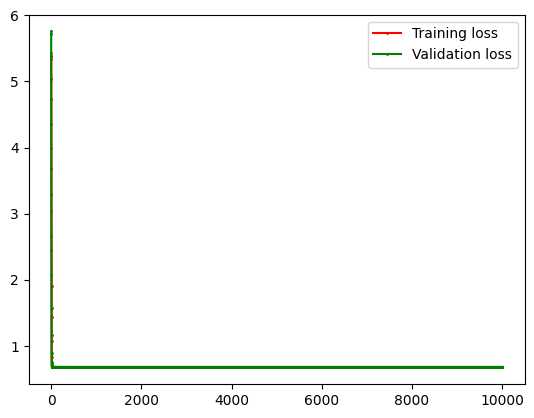

Model parameters (weights): [[-0.01249206]
 [ 0.02228109]
 [ 0.00731174]
 [ 0.02160094]
 [ 0.03647292]
 [ 0.01868654]
 [ 0.01769178]
 [ 0.01789019]
 [ 0.01923883]
 [ 0.02027882]
 [ 0.01914643]
 [ 0.02013799]
 [ 0.02095232]
 [ 0.00458568]
 [ 0.00311998]
 [ 0.00605684]
 [ 0.00705284]
 [ 0.00742952]
 [ 0.00627274]
 [ 0.02328098]
 [ 0.02385686]
 [ 0.02565637]
 [ 0.02391417]
 [ 0.02520387]
 [ 0.02375411]
 [ 0.03462815]
 [ 0.03522777]
 [ 0.03662822]
 [ 0.03649798]
 [ 0.036714  ]
 [ 0.03671077]
 [-0.01304758]
 [ 0.00456383]
 [-0.00644573]
 [-0.00238571]
 [-0.00519696]
 [-0.00335385]
 [-0.0124363 ]
 [-0.02754184]
 [-0.00523545]
 [-0.00983527]
 [-0.0041134 ]
 [-0.01539004]
 [-0.00700335]
 [-0.0017571 ]
 [-0.00552268]
 [-0.00863107]
 [-0.00523874]
 [-0.01145154]
 [-0.00881981]
 [-0.00133932]
 [-0.00757033]
 [-0.00632656]
 [-0.0080036 ]
 [-0.00210421]
 [-0.00160616]
 [-0.00839356]
 [-0.01317914]
 [-0.00861225]
 [-0.01061584]
 [-0.01525315]
 [-0.00042755]
 [ 0.00442472]
 [-0.01255564]
 [-0.0094437

In [96]:
model_l2_100 = train_realworld_model(
    X_train, y_train,
    lr=0.1,
    n_iteration=10000,
    reg_type='l2',
    reg_lambda=100
)

print("Model parameters (weights):", model_l2_100.W)
print("Sum of absolute values of weights:", np.sum(np.abs(model_l2_100.W)))

---
### Q5 (b): Evaluation for No Regularization
---

Real-World Classification | No Regularization
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


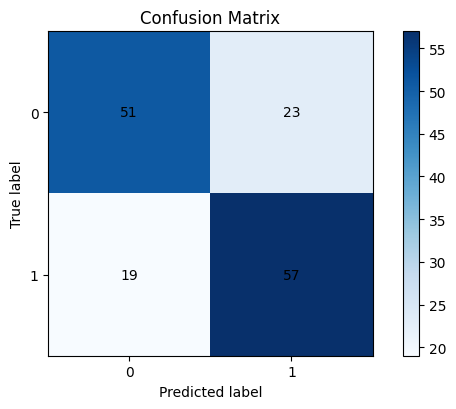

{'Accuracy': 0.72,
 'Precision': 0.7125,
 'Recall': 0.75,
 'F1-score': 0.7307692307692307}

In [97]:
y_pred_no_reg = model_no_reg.predict(X_test)
evaluate_binary_classifier(
    y_true=y_test,
    y_pred=y_pred_no_reg,
    title='Real-World Classification | No Regularization'
)

---
### Q5 (b): Evaluation for L2 (Lambda = 0.01)
---

Real-World Classification | L2 Regularization (lambda=0.01)
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


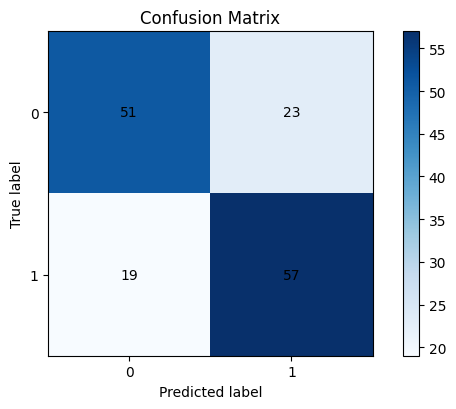

{'Accuracy': 0.72,
 'Precision': 0.7125,
 'Recall': 0.75,
 'F1-score': 0.7307692307692307}

In [98]:
y_pred_l2_001 = model_l2_001.predict(X_test)
evaluate_binary_classifier(
    y_true=y_test,
    y_pred=y_pred_l2_001,
    title='Real-World Classification | L2 Regularization (lambda=0.01)'
)

---
### Evaluation for Lambda = 1 and 100
---

Real-World Classification | L2 Regularization (lambda=1)
Accuracy  : 0.7400
Precision : 0.7342
Recall    : 0.7632
F1-score  : 0.7484


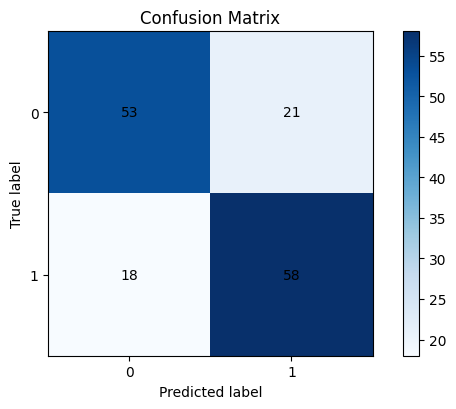

Real-World Classification | L2 Regularization (lambda=100)
Accuracy  : 0.5067
Precision : 0.5067
Recall    : 1.0000
F1-score  : 0.6726


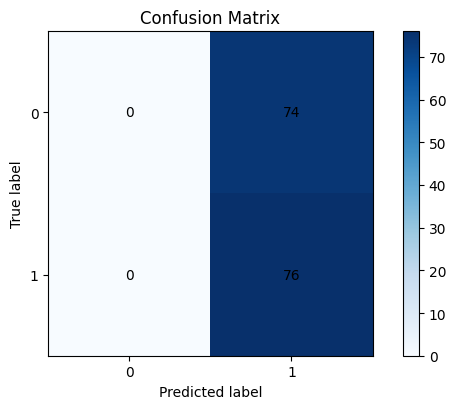

{'Accuracy': 0.5066666666666667,
 'Precision': 0.5066666666666667,
 'Recall': 1.0,
 'F1-score': 0.672566371681416}

In [99]:
y_pred_l2_1 = model_l2_1.predict(X_test)
evaluate_binary_classifier(
    y_true=y_test,
    y_pred=y_pred_l2_1,
    title='Real-World Classification | L2 Regularization (lambda=1)'
)

y_pred_l2_100 = model_l2_100.predict(X_test)
evaluate_binary_classifier(
    y_true=y_test,
    y_pred=y_pred_l2_100,
    title='Real-World Classification | L2 Regularization (lambda=100)'
)